# 05_EnvParamMeans_GTstudentproject_B 


*05_EnvParamMeans_GNNprojectGT.csv* is the dataset of environmental parameter means (post harmonization process) used to estimate diatom sampling operations' pressure status.

This file contains the following columns:

-   *CodeSite_SamplingOperations*: code of the site of the diatom sampling operation (and thus of the abiotic parameter measure).

-   *SamplingOperations_code*: code of the diatom sampling operation that the parameter measure relates to.

-   *Pressure*: pressure category that the abiotic parameter belongs to.

-   *Parameter_code*: numerical SANDRE code of the abiotic parameter in Naiades.

-   *Parameter_label*: full name of the abiotic parameter.

-   *Mean1Y*: mean of the abiotic parameter over the year (365 days) prior to the diatom sampling operation.

-   *Mean180Daysaysaysaysaysaysaysaysaysaysaysaysaysaysaysaysaysaysaysaysaysays*: mean of the abiotic parameter over the 180 days prior to the diatom sampling operation.

-   *Mean90D*: mean of the abiotic parameter over the 90 days prior to the diatom sampling operation.

Additional information about parameter units and pressure category threshold values can be found in the file *06_ListEnvParamPressure_GNNprojectGT.csv*.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import LogNorm
import plotly.express as px
from sklearn.preprocessing import StandardScaler, RobustScaler


In [3]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)

In [4]:
path = "../../data/raw/"
dfs = {}

# read all dataframes and keep them in dfs
for parquet in os.listdir(path):  # List all files in the directory
    if parquet.endswith(".parquet"):
        name = parquet.split(".parquet")[0]  # Get name without extension
        dfs[name] = pd.read_parquet(os.path.join(path, parquet))  # Use os.path.join for paths
        print(f"Loaded {name} with shape {dfs[name].shape}")

Loaded 01_DiatomInventories_GTstudentproject_B with shape (1643872, 8)
Loaded 02_InfoSites_GTstudentproject_B with shape (8404, 11)
Loaded 03_IBD_GTstudentproject_test with shape (5063, 2)
Loaded 03_IBD_GTstudentproject_train with shape (43783, 4)
Loaded 04_PressureStatus_GTstudentproject_B with shape (49231, 30)
Loaded 05_EnvParamMeans_GTstudentproject_B with shape (3763903, 8)
Loaded 06_ListEnvParam_GNNprojectGT_B with shape (192, 14)
Loaded 07_TaxaCode_GTstudentproject_B with shape (2292, 2)


In [5]:
dfs[list(dfs.keys())[5]] 

,CodeSite_SamplingOperations,SamplingOperations_code,Pressure,Parametre_code,Parametre_label,Mean1Y,Mean180Days,Mean90Days
0,2000008,S02000008_20170703,Nitrogen compounds,1319,Azote Kjeldahl,0.335000,0.335000,0.33500
1,2000008,S02000008_20170703,Nitrogen compounds,1335,Ammonium,0.103333,0.103333,0.05000
2,2000008,S02000008_20170703,Nitrogen compounds,1339,Nitrites,0.113333,0.113333,0.12000
3,2000008,S02000008_20170703,Nitrates,1340,Nitrates,18.600000,18.600000,16.00000
4,2000008,S02000008_20200708,Nitrogen compounds,1335,Ammonium,0.210000,0.210000,0.29000
...,...,...,...,...,...,...,...,...
3763898,6940940,S06940940_20230623,Pesticides,1699,Diquat,0.020000,0.020000,0.02000
3763899,6940940,S06940940_20230623,Pesticides,1700,Fenpropidine,0.006500,0.006500,0.00650
3763900,6940940,S06940940_20230623,Pesticides,1911,Imazaméthabenz-méthyl,0.006500,0.006500,0.00650
3763901,6940940,S06940940_20230623,Pesticides,1975,fosetyl-aluminium,0.013500,0.013500,0.01350


In [6]:
dfs[list(dfs.keys())[5]].nunique()

CodeSite_SamplingOperations      8404
SamplingOperations_code         49231
Pressure                           10
Parametre_code                    172
Parametre_label                   172
Mean1Y                         167511
Mean180Days                     77583
Mean90Days                      38782
dtype: int64

In [ ]:
# ---- DATA ----
# df = your 3,763,903×8 DataFrame
df = dfs[list(dfs.keys())[5]] 
df['Pressure'] = df['Pressure'].astype('category')

mean_cols = ['Mean1Y', 'Mean180Days', 'Mean90Days']
for c in mean_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').astype('float32')

C:\Users\herie\AppData\Local\Temp\ipykernel_40628\718634590.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  qs = g.groupby('Pressure')[col].quantile([0.10,0.25,0.50,0.75,0.90]).unstack()
C:\Users\herie\AppData\Local\Temp\ipykernel_40628\718634590.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  qs = g.groupby('Pressure')[col].quantile([0.10,0.25,0.50,0.75,0.90]).unstack()
C:\Users\herie\AppData\Local\Temp\ipykernel_40628\718634590.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or 

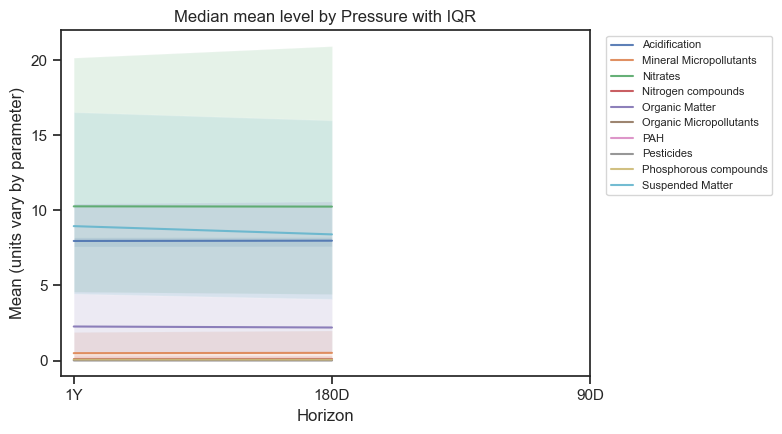

In [11]:
# Slopegraph of medians with IQR (by Pressure, across horizons) 
def qsum(col):
    g = df[['Pressure', col]].dropna()
    qs = g.groupby('Pressure')[col].quantile([0.10,0.25,0.50,0.75,0.90]).unstack()
    qs.columns = ['p10','p25','p50','p75','p90']
    qs['h'] = col.replace('Mean','')
    return qs.reset_index()

S = pd.concat([qsum('Mean1Y'), qsum('Mean180Days'), qsum('Mean180Days')], ignore_index=True)
order_h = {'1Y': 0, '180Days': 1, '90D': 2}

plt.figure(figsize=(8, 4.5))
for pr, g in S.groupby('Pressure'):
    g = g.sort_values('h', key=lambda s: s.map(order_h))
    x = [order_h[h] for h in g['h']]
    plt.plot(x, g['p50'], lw=1.5, alpha=0.9, label=str(pr))
    # IQR bands
    plt.fill_between(x, g['p25'], g['p75'], alpha=0.15)
plt.xticks([0,1,2], ['1Y','180D','90D'])
plt.title('Median mean level by Pressure with IQR')
plt.xlabel('Horizon'); plt.ylabel('Mean (units vary by parameter)')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()

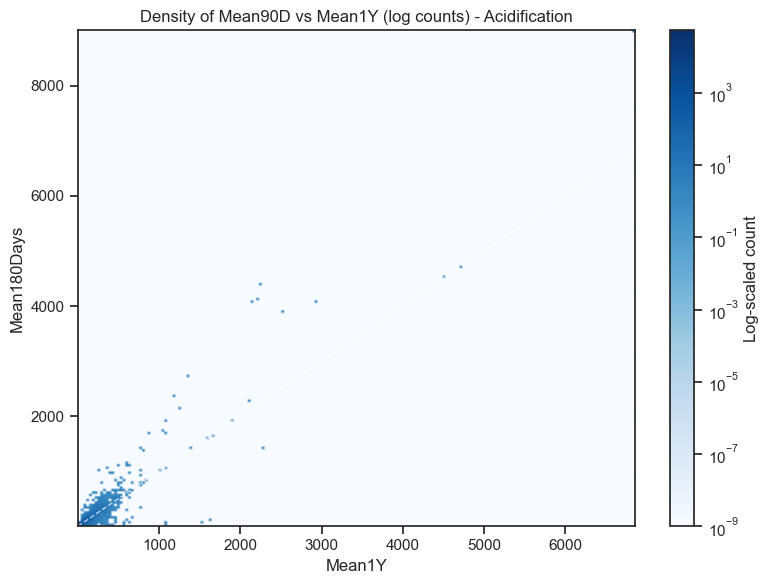

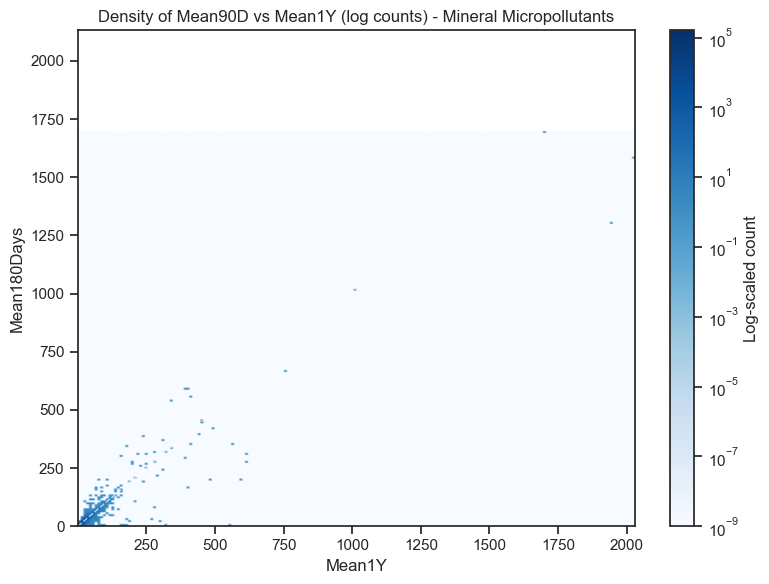

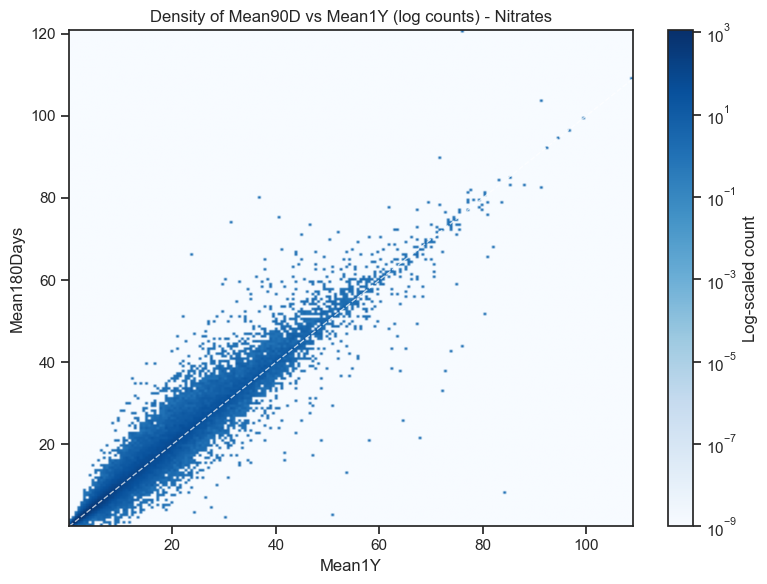

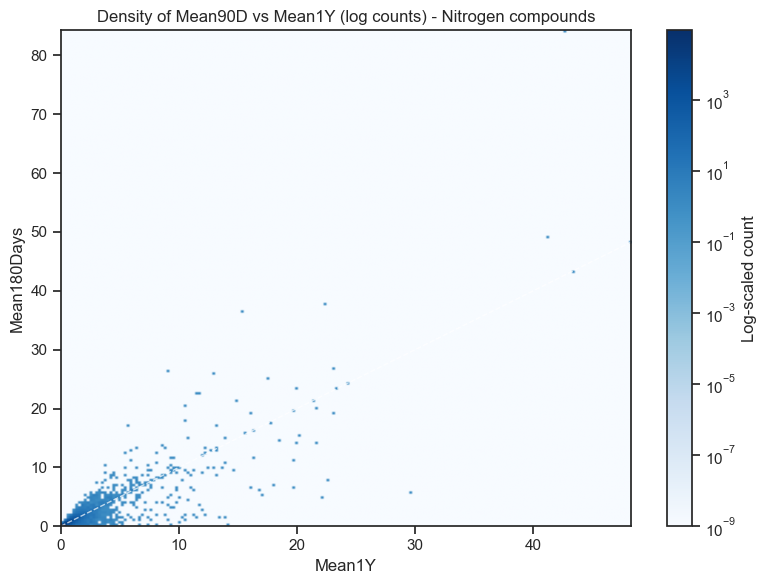

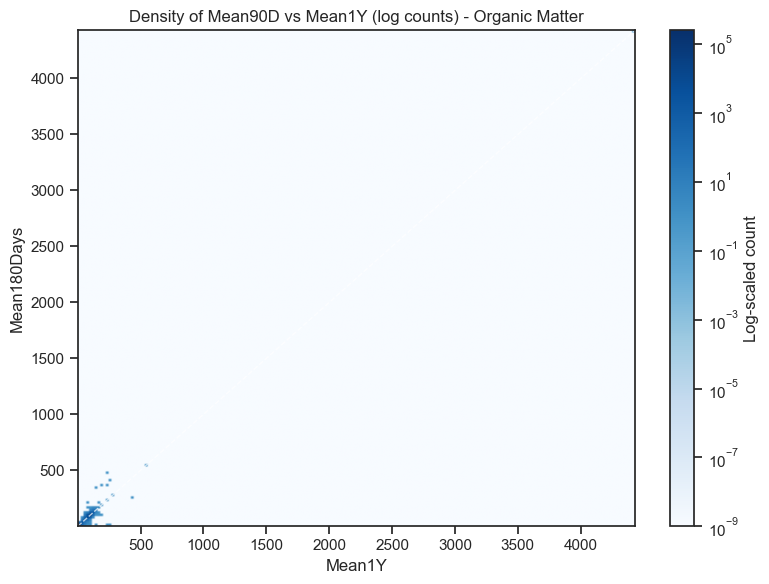

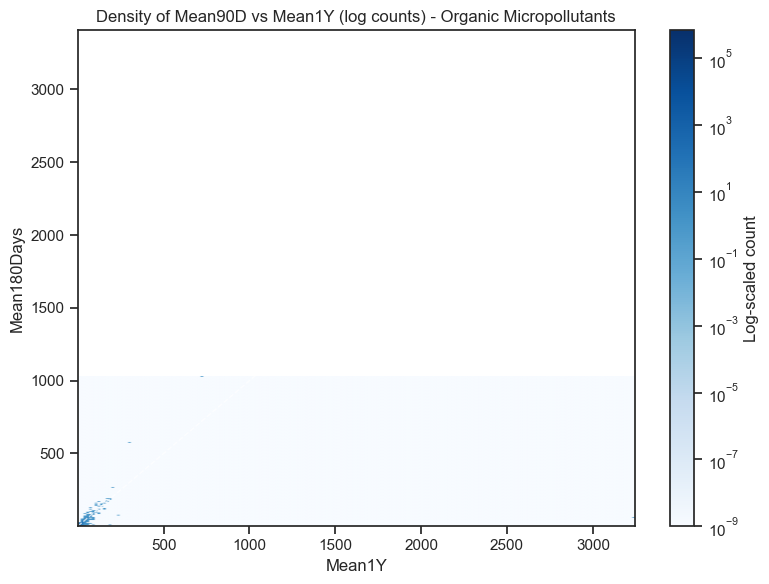

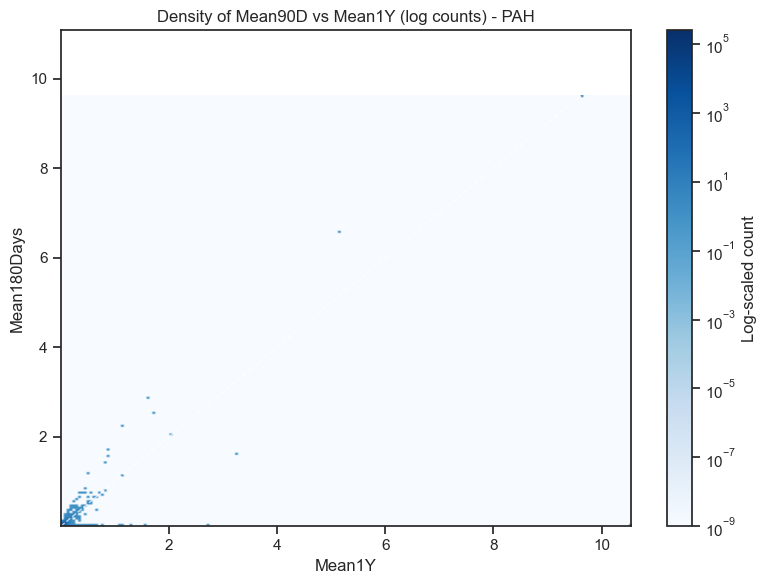

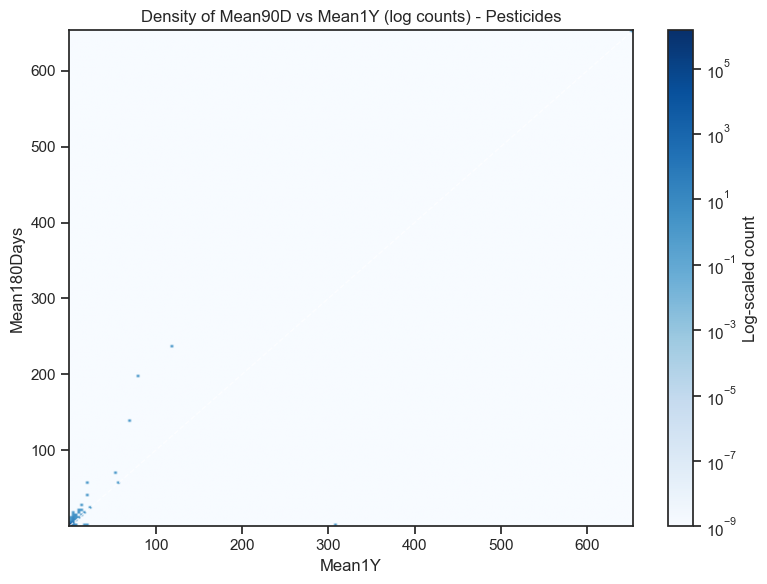

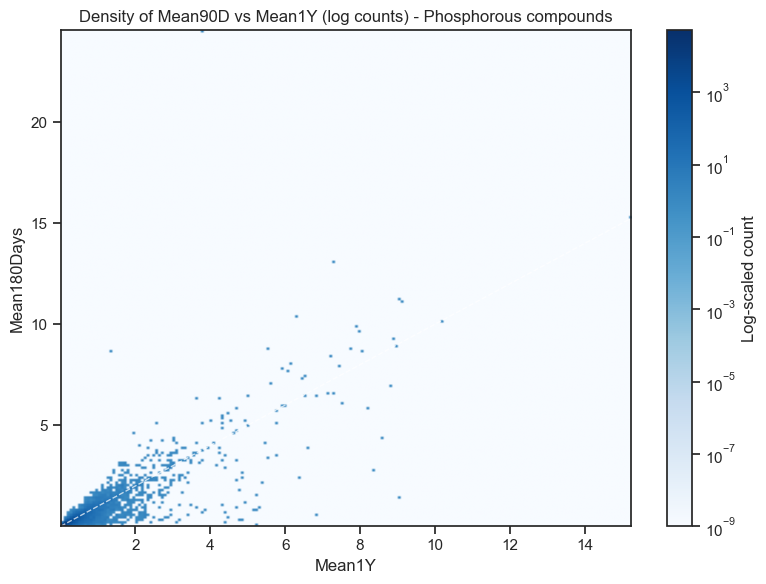

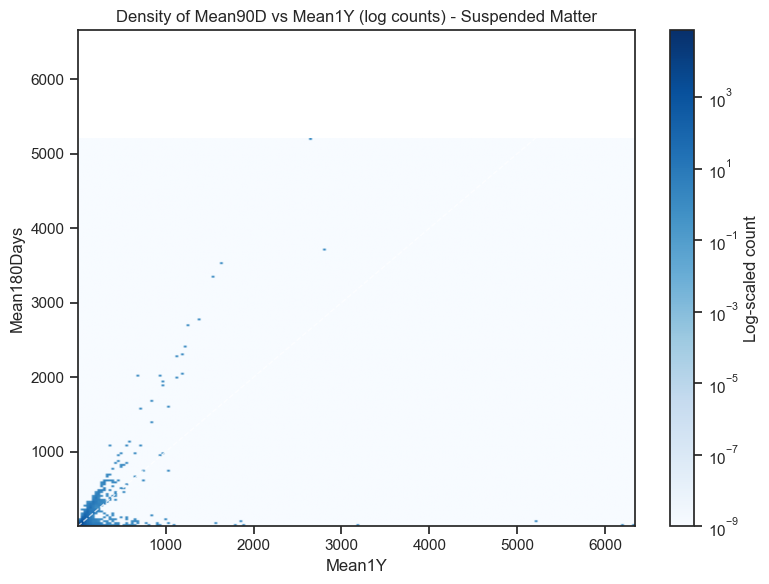

In [24]:
# 2D binned heatmaps: Mean1Y vs Mean90D, faceted by Pressure
pressures = df['Pressure'].cat.categories.tolist()
n = len(pressures)
cols = min(3, n)
rows = int(np.ceil(n / cols))

# 2D binned heatmaps: Mean1Y vs Mean90D, plotted individually by Pressure
for pr in pressures:
    sub = df.loc[df['Pressure'] == pr, ['Mean1Y', 'Mean180Days']].dropna()
    if sub.empty:
        continue
    H, xedges, yedges = np.histogram2d(sub['Mean1Y'], sub['Mean180Days'], bins=[xbins, ybins])
    
    plt.figure(figsize=(8, 6))
    plt.imshow(H.T + 1e-9, origin='lower',
               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
               aspect='auto', norm=LogNorm(), cmap='Blues')
    plt.plot([xedges[0], xedges[-1]], [xedges[0], xedges[-1]], ls='--', lw=1, c='white', alpha=0.7)
    plt.title(f'Density of Mean90D vs Mean1Y (log counts) - {pr}')
    plt.xlabel('Mean1Y')
    plt.ylabel('Mean180Days')
    plt.colorbar(label='Log-scaled count')
    plt.tight_layout()
    plt.show()


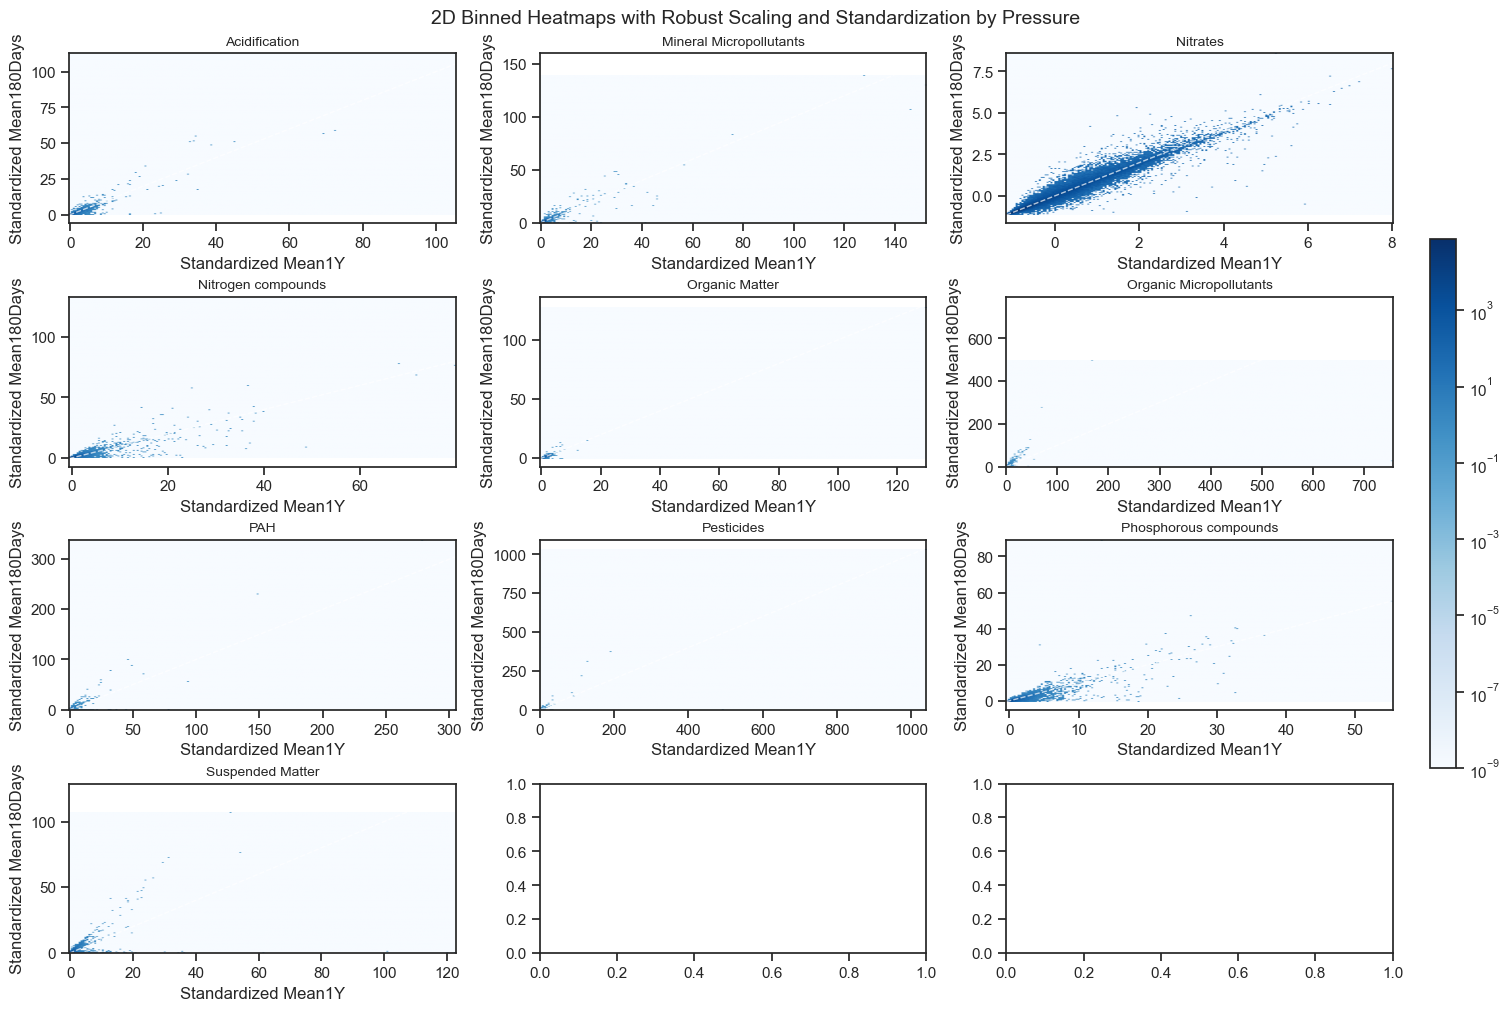

In [ ]:
# Initialize the robust scaler and standard scaler
scaler = RobustScaler()
standardizer = StandardScaler()

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 10), constrained_layout=True)
axes = axes.flatten()

# Iterate over each pressure category
for i, pr in enumerate(pressures):
    sub = df.loc[df['Pressure'] == pr, ['Mean1Y', 'Mean180Days']].dropna()
    if sub.empty:
        continue
    
    # Apply robust scaling
    scaled_data = scaler.fit_transform(sub)
    sub_scaled = pd.DataFrame(scaled_data, columns=['Mean1Y', 'Mean180Days'])
    
    # Apply standardization
    standardized_data = standardizer.fit_transform(sub_scaled)
    sub_standardized = pd.DataFrame(standardized_data, columns=['Mean1Y', 'Mean180Days'])
    
    # 2D histogram
    H, xedges, yedges = np.histogram2d(sub_standardized['Mean1Y'], sub_standardized['Mean180Days'], bins=[xbins, ybins])
    
    # Plot heatmap
    ax = axes[i]
    im = ax.imshow(H.T + 1e-9, origin='lower',
                   extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                   aspect='auto', norm=LogNorm(), cmap='Blues')
    ax.plot([xedges[0], xedges[-1]], [xedges[0], xedges[-1]], ls='--', lw=1, c='white', alpha=0.7)
    ax.set_title(pr, fontsize=10)
    ax.set_xlabel('Standardized Mean1Y')
    ax.set_ylabel('Standardized Mean180Days')

# Add a colorbar
fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
plt.suptitle('2D Binned Heatmaps with Robust Scaling and Standardization by Pressure', fontsize=14)
plt.show()


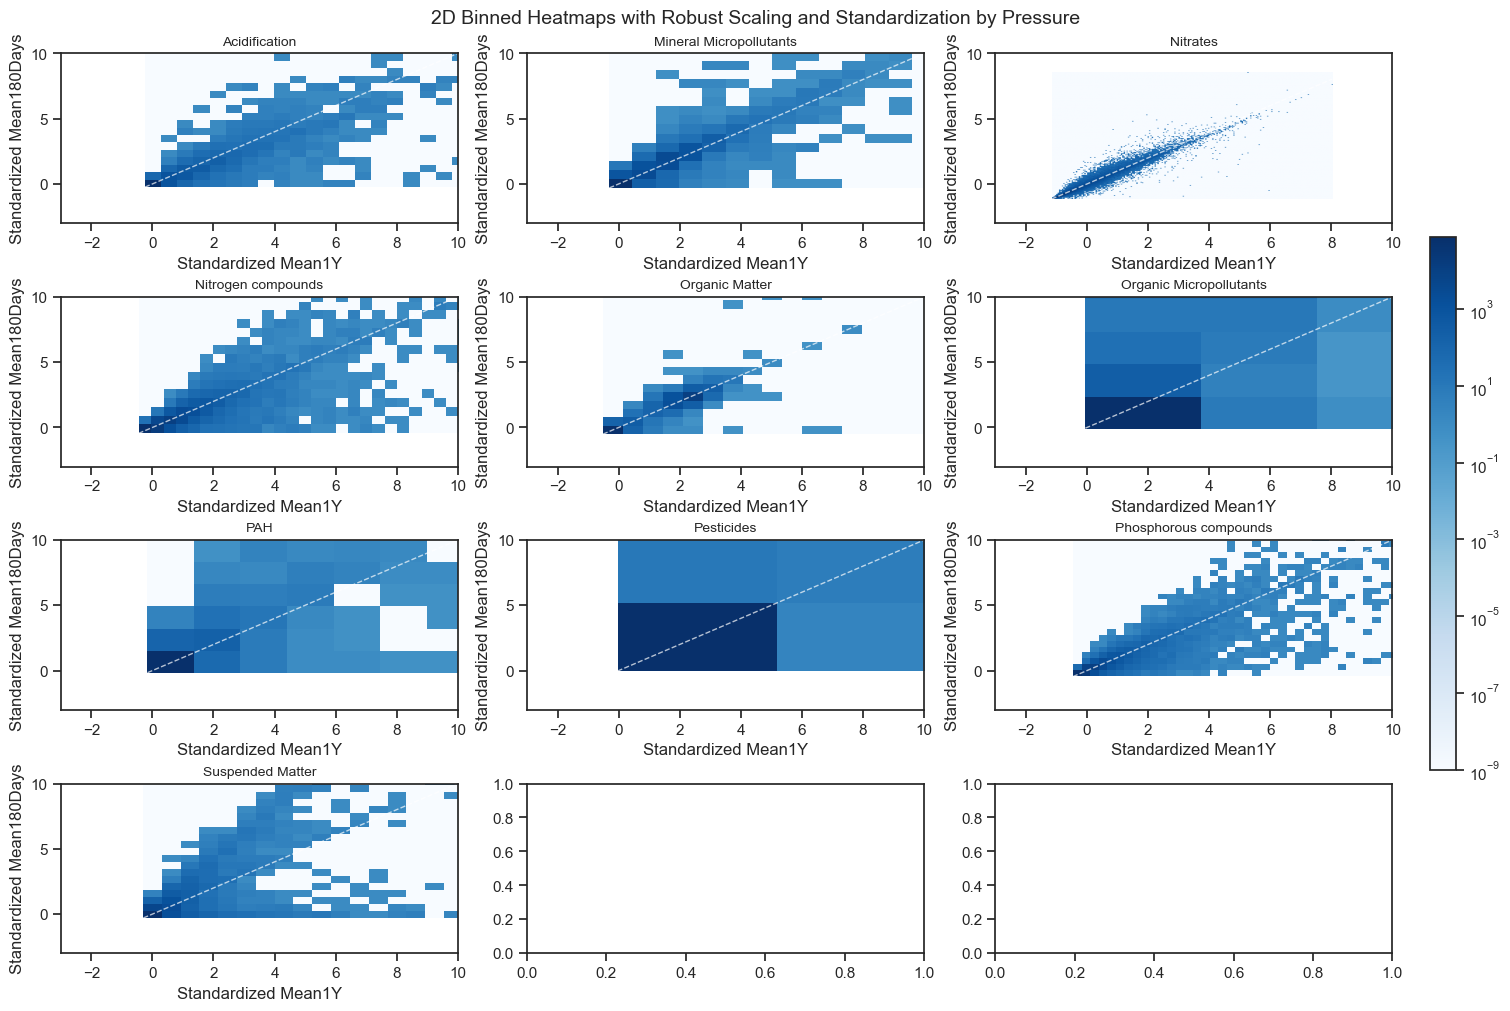

In [ ]:
# Initialize the robust scaler and standard scaler
scaler = RobustScaler()
standardizer = StandardScaler()

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 10), constrained_layout=True)
axes = axes.flatten()

# Iterate over each pressure category
for i, pr in enumerate(pressures):
    sub = df.loc[df['Pressure'] == pr, ['Mean1Y', 'Mean180Days']].dropna()
    if sub.empty:
        continue
    
    # Apply robust scaling
    scaled_data = scaler.fit_transform(sub)
    sub_scaled = pd.DataFrame(scaled_data, columns=['Mean1Y', 'Mean180Days'])
    
    # Apply standardization
    standardized_data = standardizer.fit_transform(sub_scaled)
    sub_standardized = pd.DataFrame(standardized_data, columns=['Mean1Y', 'Mean180Days'])
    
    # 2D histogram
    H, xedges, yedges = np.histogram2d(sub_standardized['Mean1Y'], sub_standardized['Mean180Days'], bins=[xbins, ybins])
    
    # Plot heatmap
    ax = axes[i]
    im = ax.imshow(H.T + 1e-9, origin='lower',
                   extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                   aspect='auto', norm=LogNorm(), cmap='Blues')
    ax.plot([xedges[0], xedges[-1]], [xedges[0], xedges[-1]], ls='--', lw=1, c='white', alpha=0.7)
    ax.set_title(pr, fontsize=10)
    ax.set_xlabel('Standardized Mean1Y')
    ax.set_ylabel('Standardized Mean180Days')
    ax.set_xlim(-3, 10)
    ax.set_ylim(-3, 10)

# Add a colorbar
fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
plt.suptitle('2D Binned Heatmaps with Robust Scaling and Standardization by Pressure', fontsize=14)
plt.show()


C:\Users\herie\AppData\Local\Temp\ipykernel_40628\106559283.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Q = (valid.groupby('Pressure')['d_log']


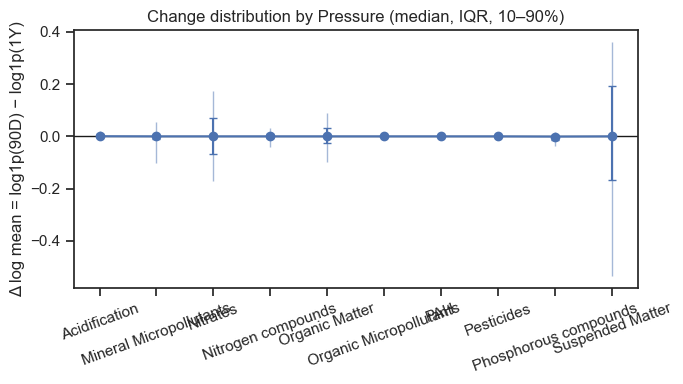

In [33]:
 # Δ-change summary: log-scale robust change by Pressure
# Scale-invariant delta: d = log1p(Mean90D) - log1p(Mean1Y)
valid = df[['Pressure','Mean1Y','Mean180Days']].dropna()
valid = valid[valid[['Mean1Y','Mean180Days']].ge(0).all(1)]  # log1p requires ≥0
valid['d_log'] = np.log1p(valid['Mean180Days']) - np.log1p(valid['Mean1Y'])
Q = (valid.groupby('Pressure')['d_log']
          .quantile([0.10,0.25,0.50,0.75,0.90]).unstack())
Q.columns = ['p10','p25','p50','p75','p90']
Q = Q.reset_index()

plt.figure(figsize=(7,4))
x = np.arange(len(Q))
plt.errorbar(x, Q['p50'], yerr=[Q['p50']-Q['p25'], Q['p75']-Q['p50']],
             fmt='o-', capsize=3, lw=1.5)
plt.vlines(x, Q['p10'], Q['p90'], lw=1, alpha=0.5)  # whiskers
plt.axhline(0, color='k', lw=1)
plt.xticks(x, Q['Pressure'], rotation=20)
plt.ylabel('Δ log mean = log1p(90D) − log1p(1Y)')
plt.title('Change distribution by Pressure (median, IQR, 10–90%)')
plt.tight_layout()

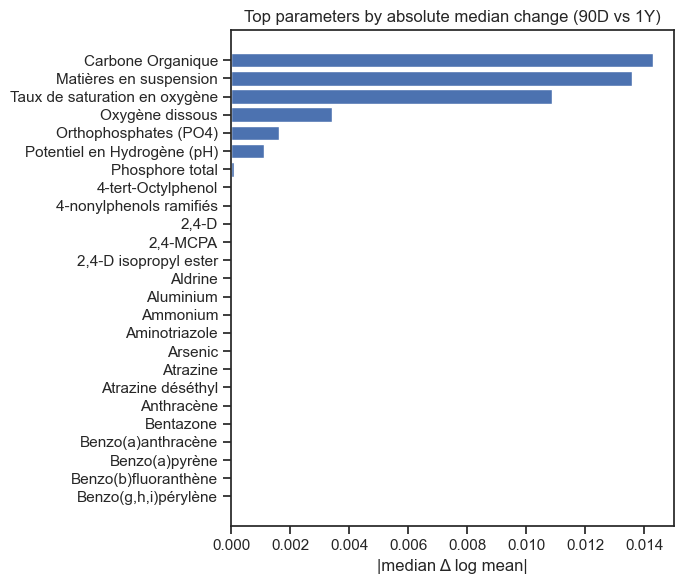

In [ ]:
# Parameter leaderboard: biggest median |Δ log mean| 
dpar = df[['Parametre_label','Mean1Y','Mean180Days']].dropna()
dpar = dpar[dpar[['Mean1Y','Mean180Days']].ge(0).all(1)]
dpar['d_log'] = np.log1p(dpar['Mean180Days']) - np.log1p(dpar['Mean1Y'])
L = (dpar.groupby('Parametre_label')['d_log'].median()
         .abs().sort_values(ascending=False).head(25))
plt.figure(figsize=(7,6))
plt.barh(L.index[::-1], L.values[::-1])
plt.xlabel('|median Δ log mean|'); plt.title('Top parameters by absolute median change (90D vs 1Y)')
plt.tight_layout()

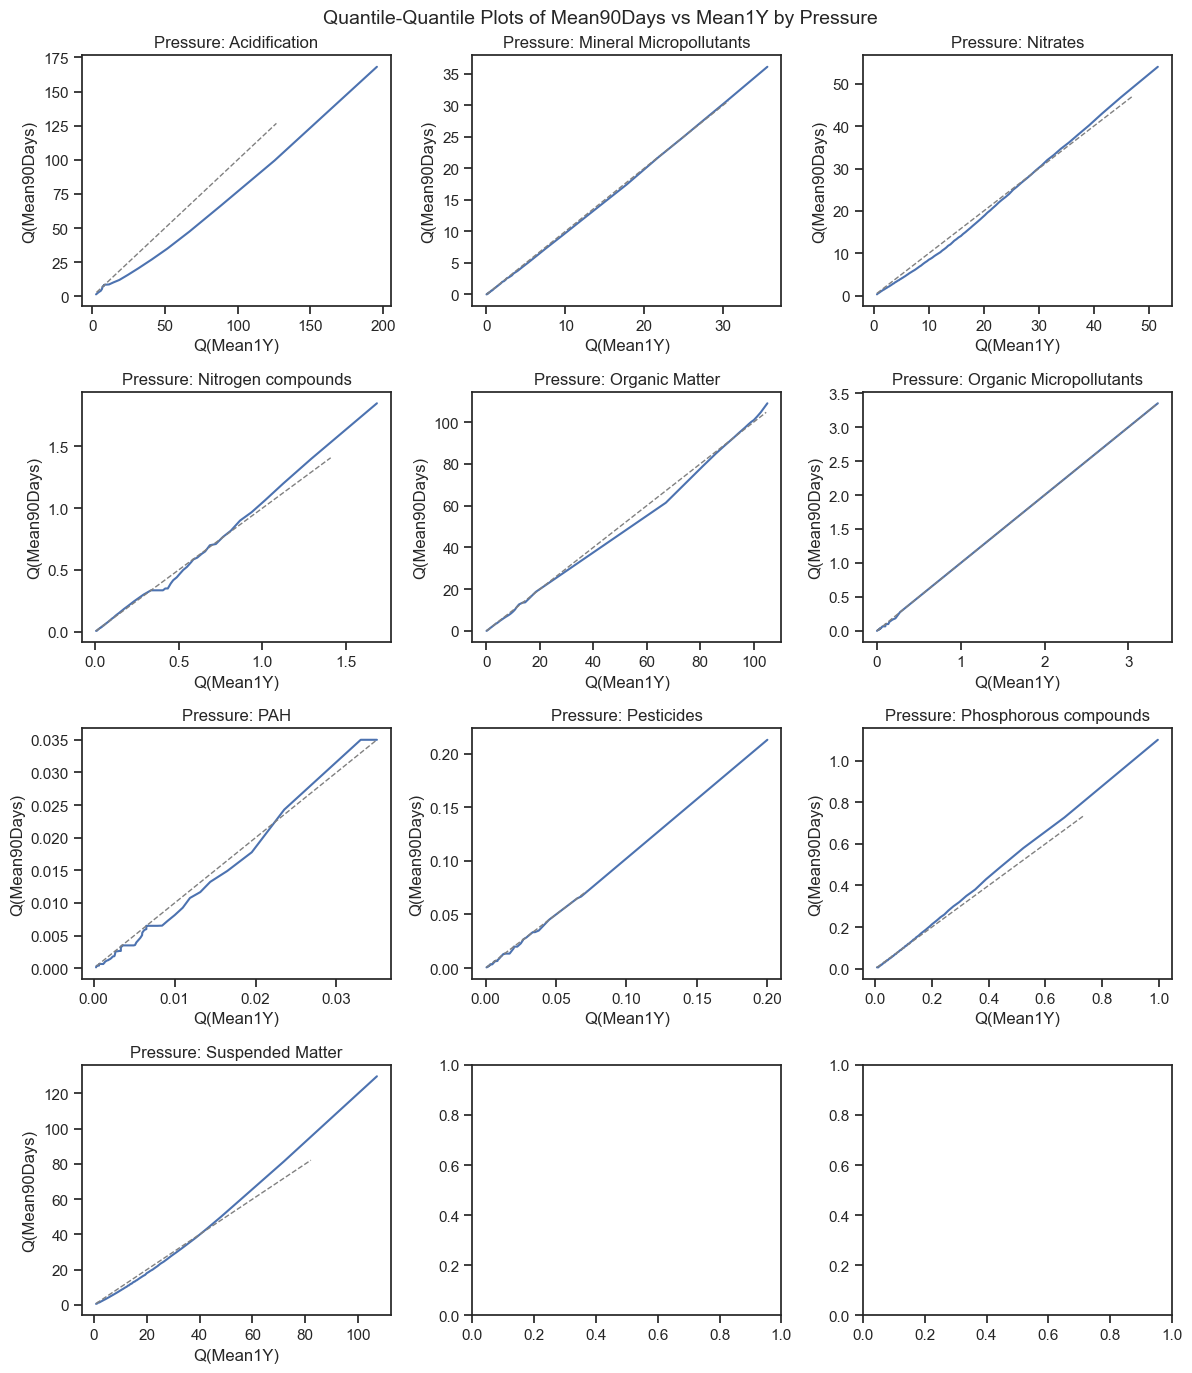

In [38]:
qs = np.linspace(0.01, 0.99, 99)
n = len(pressures); cols = min(3, n); rows = int(np.ceil(n/cols))
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.5*rows), sharex=False, sharey=False)
axes = np.atleast_2d(axes)

for i, pr in enumerate(pressures):
    ax = axes[i//cols, i%cols]
    sub = df.loc[df['Pressure']==pr, ['Mean1Y','Mean90Days']].dropna()
    if sub.empty: ax.set_visible(False); continue
    q1 = np.quantile(sub['Mean1Y'], qs)
    q9 = np.quantile(sub['Mean90Days'], qs)
    ax.plot(q1, q9, lw=1.5)
    lim = np.nanpercentile(np.r_[q1,q9], [1,99])
    ax.plot([lim[0], lim[1]], [lim[0], lim[1]], ls='--', lw=1, c='gray')
    ax.set_title(str(pr)); ax.set_xlabel('Q(Mean1Y)'); ax.set_ylabel('Q(Mean90Days)')
    ax.set_title(f'Pressure: {pr}')

plt.suptitle('Quantile-Quantile Plots of Mean90Days vs Mean1Y by Pressure', fontsize=14)
plt.tight_layout()


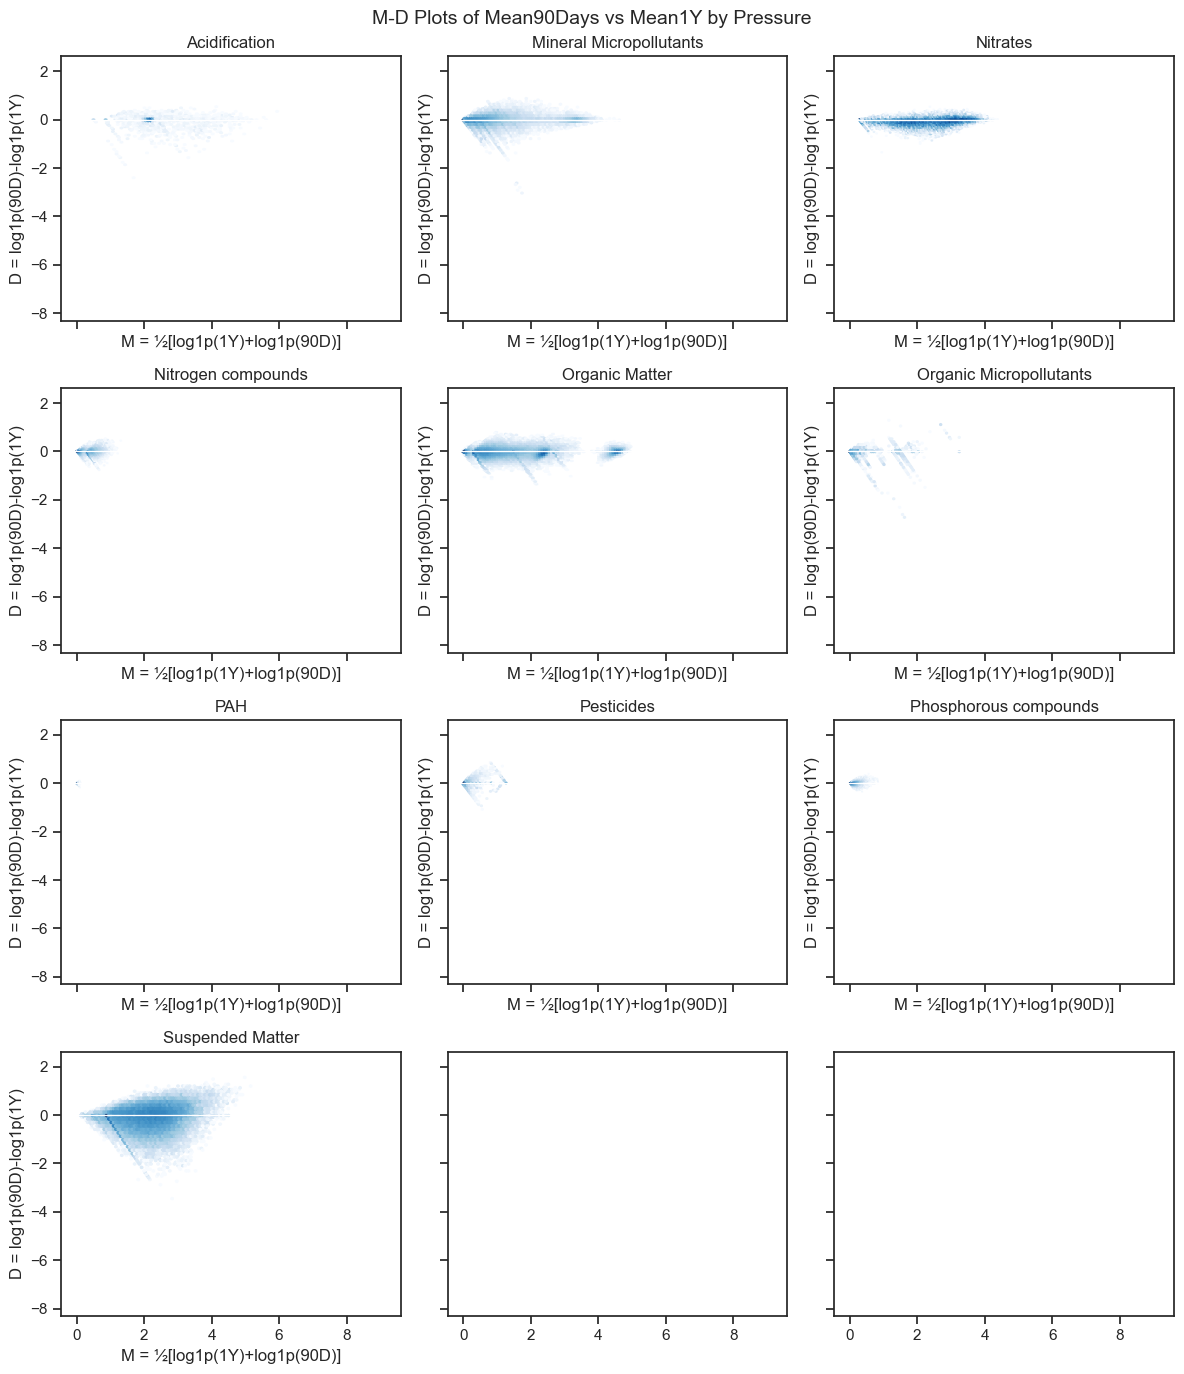

In [43]:
valid = df[(df['Mean1Y']>=0) & (df['Mean90Days']>=0)].copy()
valid['M'] = 0.5*(np.log1p(valid['Mean1Y']) + np.log1p(valid['Mean90Days']))
valid['D'] =     (np.log1p(valid['Mean90Days']) - np.log1p(valid['Mean1Y']))

n = len(pressures); cols = min(3, n); rows = int(np.ceil(n/cols))
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.5*rows), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for i, pr in enumerate(pressures):
    ax = axes[i//cols, i%cols]
    sub = valid.loc[valid['Pressure']==pr, ['M','D']]
    if sub.empty: ax.set_visible(False); continue
    hb = ax.hexbin(sub['M'], sub['D'], gridsize=120, mincnt=5, norm=LogNorm(), cmap='Blues')
    ax.axhline(0, color='white', lw=1)
    ax.set_title(str(pr)); ax.set_xlabel('M = ½[log1p(1Y)+log1p(90D)]'); ax.set_ylabel('D = log1p(90D)-log1p(1Y)')

plt.suptitle('M-D Plots of Mean90Days vs Mean1Y by Pressure', fontsize=14)
plt.tight_layout()


In [ ]:
G = (df.groupby(['Pressure','Parametre_label'])[mean_cols]
        .median().reset_index())
G['sum'] = G[mean_cols].sum(1).replace(0, np.nan)
G['w1']  = G['Mean1Y']/G['sum']
G['w18'] = G['Mean180Days']/G['sum']
G['w9']  = G['Mean90Days']/G['sum']
G['d_log'] = np.log1p(G['Mean90Days'].clip(lower=0)) - np.log1p(G['Mean1Y'].clip(lower=0))

out = []
topN = 25
for pr, sub in G.groupby('Pressure', sort=False):
    out.append(sub.nlargest(topN, 'sum'))
S = pd.concat(out, ignore_index=True)

# Remove rows with NaN values in the 'sum' column to avoid errors
S = S[S['sum'].notna()]

fig = px.scatter_ternary(
    S, a='w1', b='w18', c='w9',
    color='d_log', color_continuous_scale='Blues',
    size=np.clip(S['sum'], S['sum'].quantile(0.05), S['sum'].quantile(0.95)),
    hover_data={'Pressure':True, 'Parametre_label':True,
                'Mean1Y':':.3g','Mean180Days':':.3g','Mean90Days':':.3g','d_log':':.3g',
                'w1':':.2f','w18':':.2f','w9':':.2f'}
)
fig.update_layout(title='Parameter medians in horizon simplex (Top-N per Pressure)',
                  ternary=dict(aaxis_title='1Y', baxis_title='180D', caxis_title='90D'))
fig.show()


C:\Users\herie\AppData\Local\Temp\ipykernel_40628\3350571295.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  G = (df.groupby(['Pressure','Parametre_label'])[mean_cols]
C:\Users\herie\AppData\Local\Temp\ipykernel_40628\3350571295.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pr, sub in G.groupby('Pressure', sort=False):


C:\Users\herie\AppData\Local\Temp\ipykernel_40628\2977909837.py:17: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\herie\AppData\Local\Temp\ipykernel_40628\2977909837.py:12: RuntimeWarning:

invalid value encountered in scalar divide

C:\Users\herie\AppData\Local\Temp\ipykernel_40628\2977909837.py:18: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



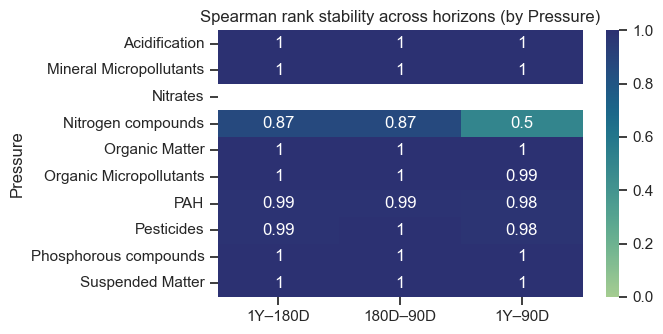

In [52]:
# per pressure, correlate parameter medians across horizons
def rho_pairs(g):
    g = g.dropna(subset=mean_cols)
    if g.empty: return pd.Series({'1Y–180D':np.nan,'180D–90D':np.nan,'1Y–90D':np.nan})
    # align vectors across parameters
    S = g.set_index('Parametre_label')[mean_cols]
    r12 = S['Mean1Y'].rank()
    r18 = S['Mean180Days'].rank()
    r9  = S['Mean90Days'].rank()
    def spearman(a,b):
        a = a - a.mean(); b = b - b.mean()
        return float((a*b).sum() / np.sqrt((a*a).sum() * (b*b).sum()))
    return pd.Series({'1Y–180D':spearman(r12,r18),
                      '180D–90D':spearman(r18,r9),
                      '1Y–90D':spearman(r12,r9)})

R = (G.groupby('Pressure')
       .apply(rho_pairs)
       .reset_index().rename(columns={'index':'Pressure'}))

plt.figure(figsize=(7, max(3, len(R)*0.35)))
sns.heatmap(R.set_index('Pressure'), vmin=0, vmax=1, annot=True, cmap='crest')
plt.title('Spearman rank stability across horizons (by Pressure)')
plt.tight_layout()
